# Chapter 8: Multivariate Descriptive Analysis

In [ ]:
%pip install seaborn

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns ; sns.set()

## 8.1 Introduction

In one of the previous chapters, we've tackled univariate descriptive analysis. This allowed us to get an idea of how certain variables in our dataset behave. Though this definitely is interesting, an even more interesting idea is to discover how variables influence each other. Are certain variables related to each other? Do they influence each other? Overall; what's the dynamics of our variables among each other? Though more interesting, this is definitely also a more difficult question.

As such, before any relationships between variables are to be studied, a univariate descriptive analysis of all those variables should be performed. Not only will this allow us to perform the multivariate analysis more focused, it is an absolute prerequise to be able to interpret the relationships among variables.

In this chapter, we get started with Multivariate Descriptive Analysis. We try to take a look at the relationships between variables, and check whether there's anything to be found there. It is the equivalent of what we've done last week, but now extended to take an explorative look at the relationships among variables.

Obviously, we'll start by importing our dataset:

In [2]:
pokemon = pd.read_csv('Pokemon.csv')
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


The setup of multivariate descriptive analysis, is that we are always pairswise studying variables. This means, that we compare two variables to each other. If we wish to include a third variable, we still do this analysis one on one.

## 4.3 Correlation

Correlation, and more specific linear correlation, is the first type of relationship we'll take a look at. The main question we ask ourself in this setting is the following: 

*Let's say that we are studying variables **x** and **y**. What happens when the value of **x** changes? Does **y** change also? Does it change in the same direction? Does it always change with the same amount?*

### 4.3.1 Graphical

Obviously, the first logical way to take a look at this is by trying to plot these variables next to each other. An opportune graph type for this is the scatterplot.

Let's do that real quick:

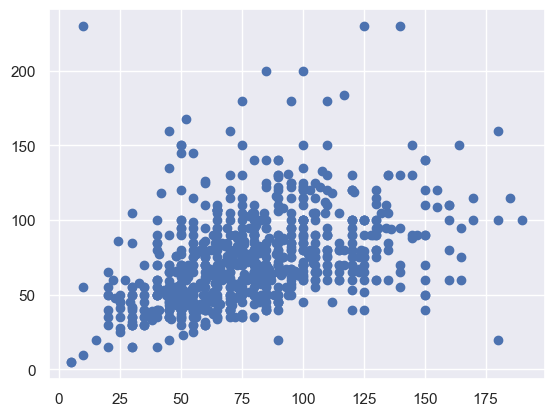

In [3]:
plt.scatter(pokemon["Attack"], pokemon["Defense"])

### Question 1: Take a look at the graph. Which conclusions can you make?

There's a few things to be noticed here. First of all, we see that the variables *Attack* and *Defense* are definitely related somehow. Let's sum up the conclusions we can take from this graph:

* There appears to be some sort of relationship between Attack and Defense.
* This relationship is **positive**: they both move in the same direction.
* This relationship resembles a **linear** relationship.

The first point should be abundandly clear by simply looking at the graph. The second point should also be, but there is some terminology in there. Positive simply means that they both move in the same direction. The data should more or less follow the line from left under to right above. This means: if attack is high, defense is probably going to be also high. If the defense is rather low, there is a good chance that the attack will also be.

When looking at these graphs, we hope to find a linear relation.

Exactly what we mean by this is best illustrated by following graph:

<Axes: xlabel='Attack', ylabel='Defense'>

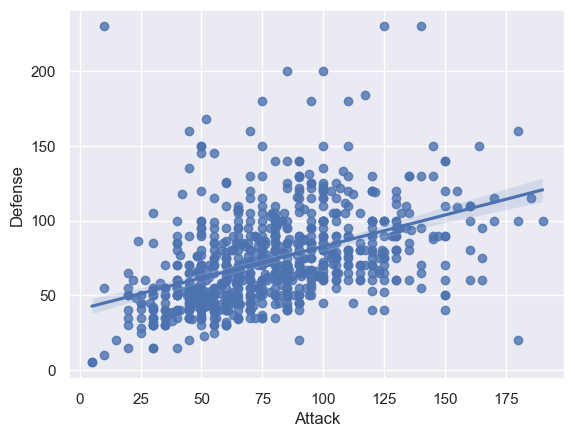

In [4]:
sns.regplot(x="Attack", y="Defense", data=pokemon)

What we mean by linear, is that the relationship more or less follows a straight line. The closer all observations lie to a certain line, the more linear the relationship is. The big question then however is, what is linear and what isn't? That's something we'll come back to in the second part of correlation, when we'll calculate the correlation metric. You should however, already think about some interesting cases:

### Question 2: think about the scenario's below:
* How would the scatterplot look when there is no noticeable relationship between the two variables?
* How would the scatterplot look when there is a relationship between the two variables, but said relationship is not linear.

When there is no noticeable relationship we expect the scatterplot would appear as a random cloud of points with no discernible pattern. The points would be spread out in various directions without forming a trend. There would be no clear upward or downward movement, meaning changes in one variable do not consistently affect the other.

When there is a non-linear relationship we expect the scatterplot would show a pattern, but not in a straight-line form. Instead, the points might follow a curve, a U-shape, or another complex pattern. For example, a quadratic relationship might create a parabolic shape, while an exponential relationship might show rapid increases or decreases. Despite a visible trend, a straight-line fit would not accurately describe the data.

It should be clear that performing such types of analysis to each pair of variables in our dataset can become extremely tedious. As such, luckily, we can also plot all of them together:

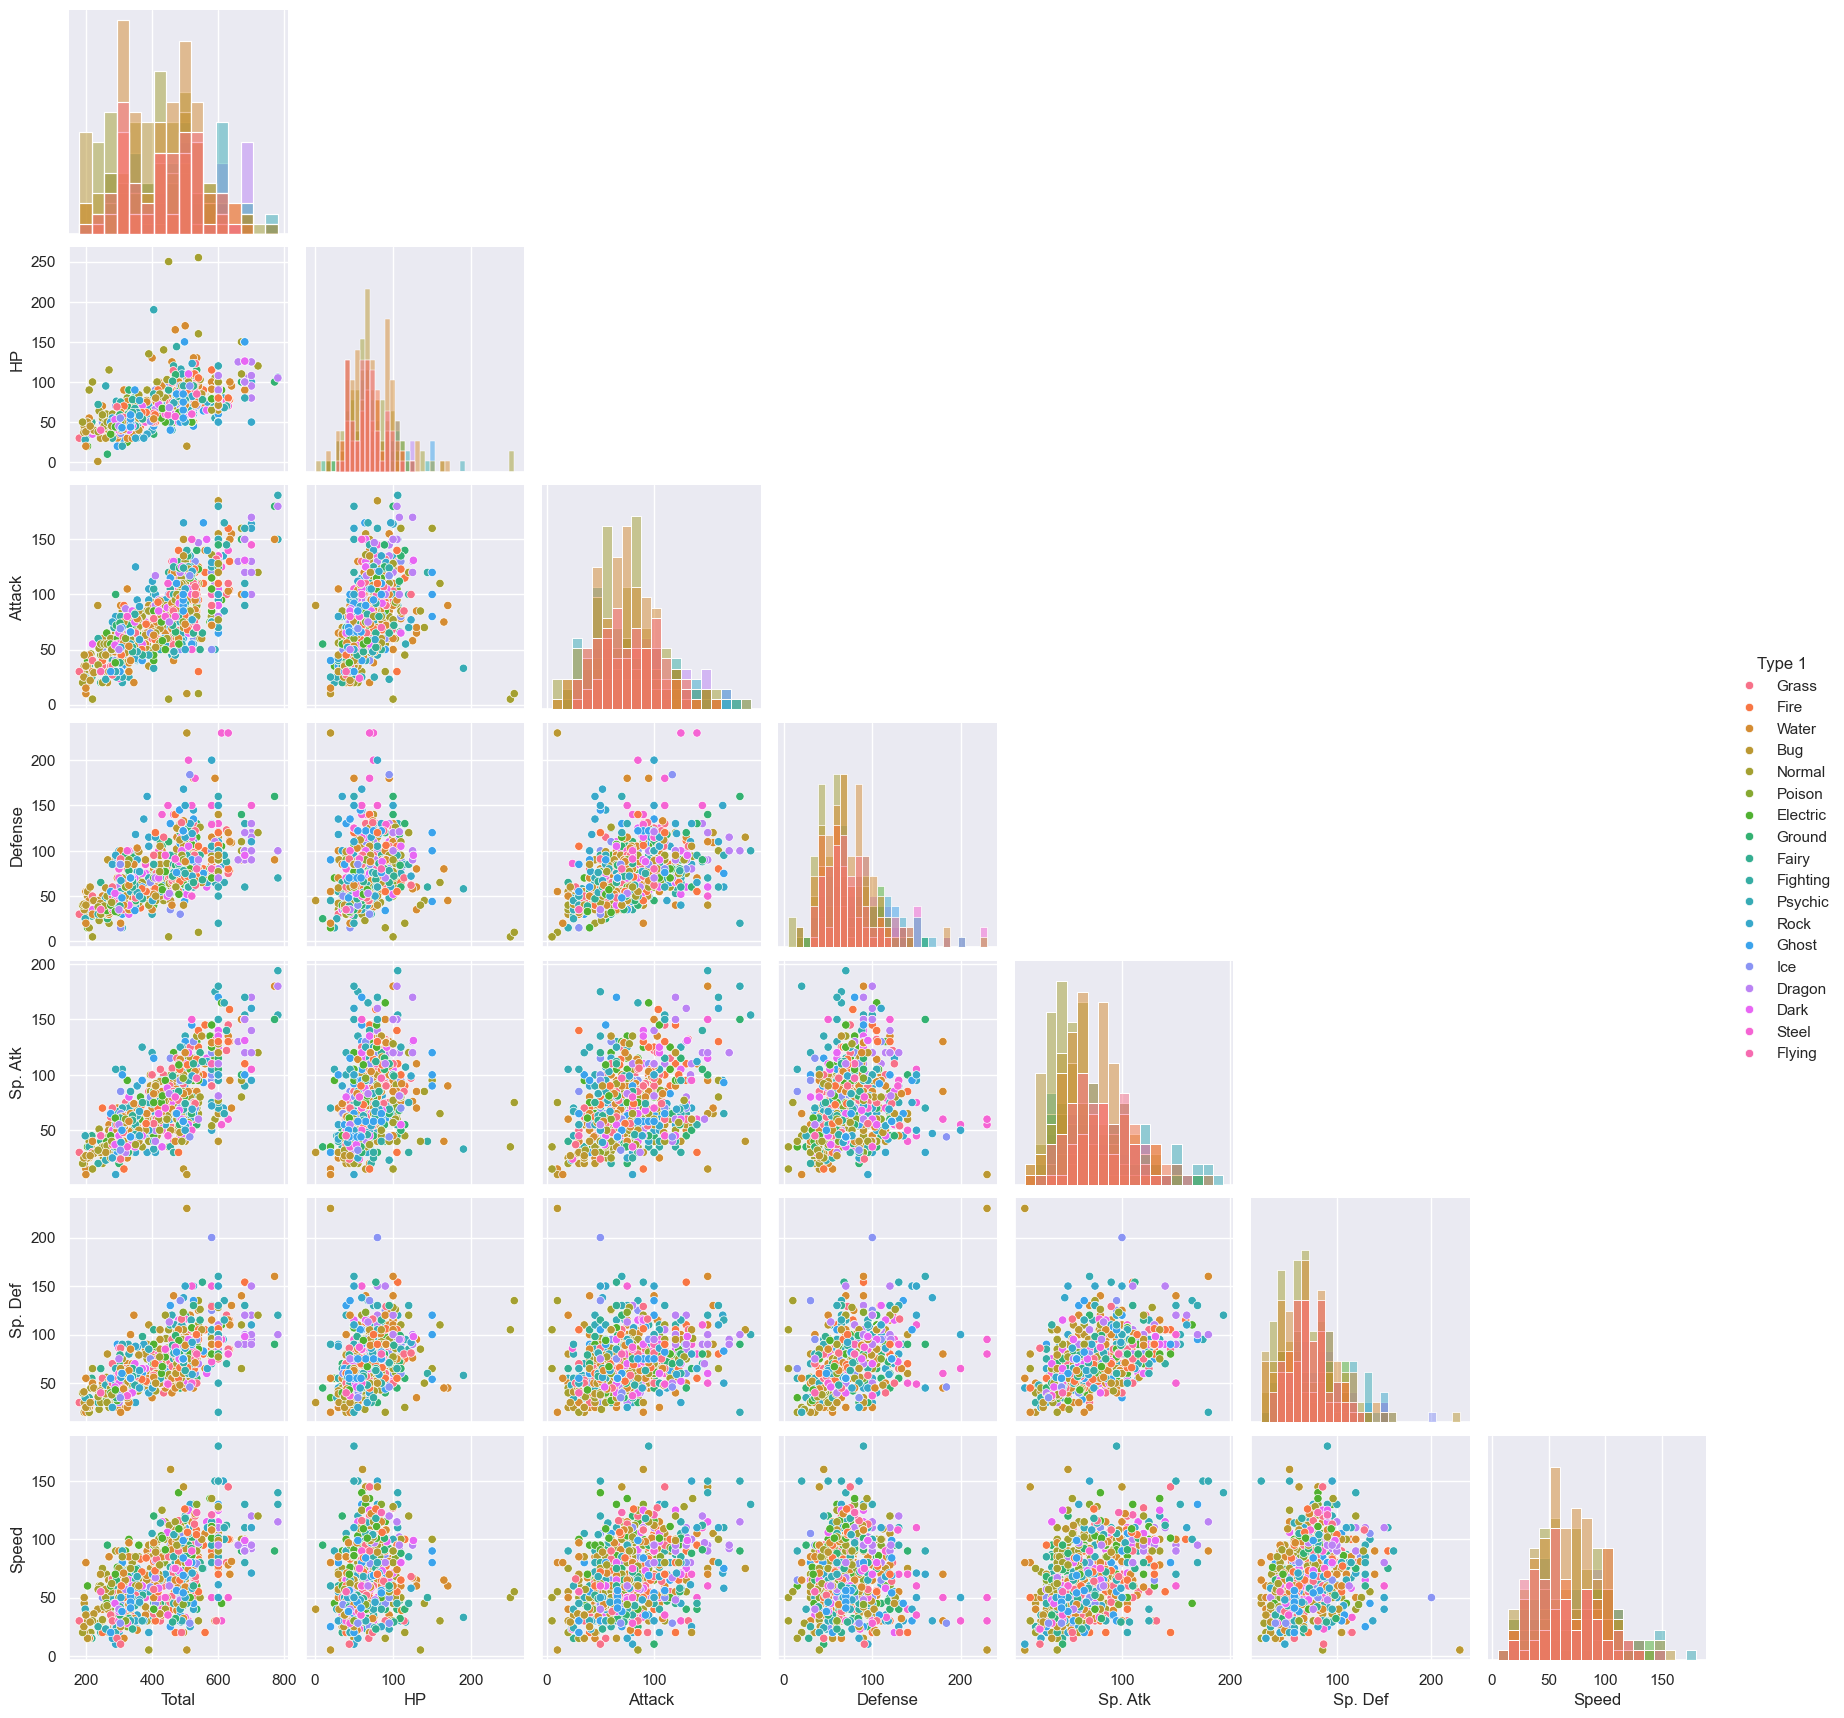

In [7]:
sns.pairplot(pokemon, vars=["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"], hue="Type 1", corner=True, kind="scatter", diag_kind="hist")

**Remark**: Note that there is an enormeous difference between ***correlation*** and ***causality***. Correlation is the fact that some variables are somehow related. This is what we studied here. Causation is the idea that one variable influences the other variable. We can't draw any conclusions about causality by studying correlation! All we can say is that they are somehow related. Does Attack influence Defense? Does Defense influence Attack? or is there a third underlying variable which influences both? We simply can't say by studying the correlation! All we can say is that they are somehow related, and that this relationship is positive and approaches a linear relationship.

### 4.3.2 Numerical

As we have already touched upon, a graph does not always say enough. For example: consider *Sp. Atk - Speed* and *Total - Sp. Def*. It is clear that one of those two relationships is more linear than the other. But does that mean that one of those two isn't linear? Is one weaker than the other? Loads of questions arise.

It is for this purpose that there exists a numerical metric for correlation, quite aptly called the ***correlation*** coefficient. The formula holds as follows:


$$ r_{x,y} = \frac{ \sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y}) }{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}} $$


Obviously, there is no need for you to know this formula. What you should notice however, is that in the denominator we find the variance of variables $x$ and $y$, and in the numerator we find some sort of metric of variance for both variables combined. It is exactly this what the correlation coefficient does. It measures just how much these variables vary **together**.

A last remark about this coefficient is that it only represents linear correlation! Non-linear correlation, as we talked about before, cannot be described by this coefficient. As such, if you were to find a low value, it only indicates that no clear linear correlation has been found. This does not at all mean that no correlation all together has been found!

With that said, let's calculate the correlation matrix:

In [8]:
pokemonstats = pokemon.drop(columns=["Name", "Type 1", "Type 2"])

In [9]:
corrMatrix = pokemonstats.corr()
corrMatrix

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.119813,0.097614,0.102298,0.094786,0.088759,0.085817,0.010733,0.982516,0.153396
Total,0.119813,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384,0.501758
HP,0.097614,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102298,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094786,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.088759,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085817,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.010733,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.982516,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.153396,0.501758,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


It is also very possible to only calculate the correlation of two variables (try this yourself!), but it is simply handier to have the correlations of all variables among each other represented in 1 measure. To further clarify what we have found in the correlations, we can plot it in a heatmap:

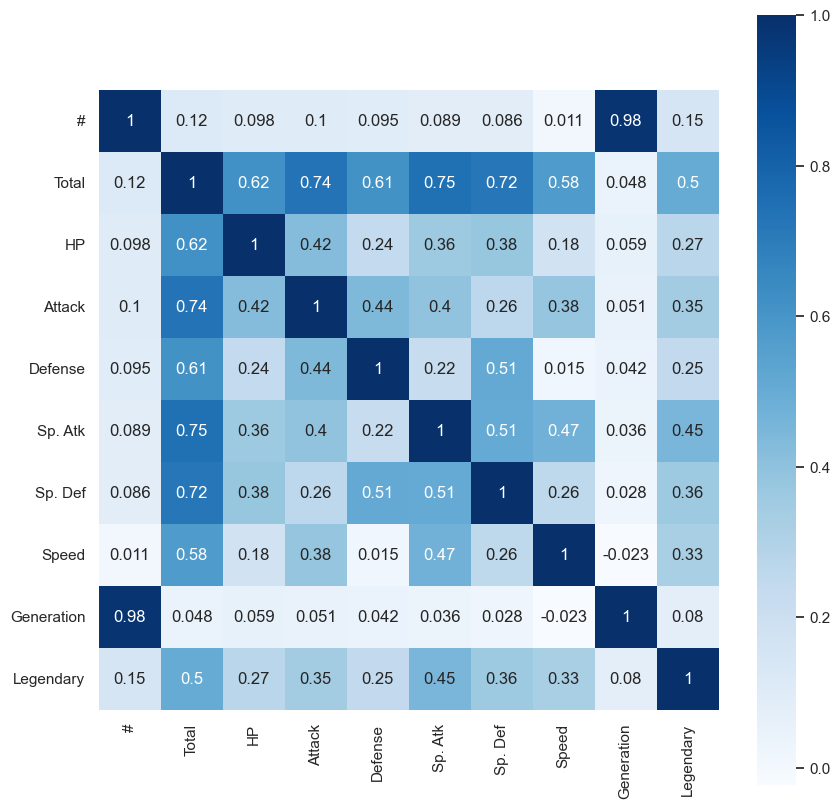

In [10]:
plt.figure(figsize=(10,10))
fig = sns.heatmap(corrMatrix, annot=True, square=True, cmap="Blues")

Let's analyze this a bit, shall we. First of all, it should be noted that the correlation coefficient **always** lies between -1 and 1. In this range: 0 stands for absolutely no linear correlation, 1 stands for perfect linear correlation, and -1 for perfectly linear anti-correlation.

It is logical that on our diagonal, we've got all ones. These are namely the variables correlated with themselves. Let's go looking for other instances of high numbers outside of the diagonal.

Firstly, generation is apparently highly correlated with the pokemon ID. Makes sense, as they convey the same information. Both of these variables are however, unfortunately irrelevant when we're trying to form general conclusions about relationships in our dataset. Both these variables are also totally not correlated with all other variables which do possess some information.

The next remark we might make, is that the variable *Total* seems to have a rather high correlation with all relevant variables. This also does really make sense as Total is a weighed average of all other variables.

These remarks indicate the issues of which we might be aware. Correlations of 0 and ±1 are almost non-existent in real-world variables. 

### Question 3: Interpret the plot above. What are some conclusions you can make? Are there some high relations? Are there low relations? Are there some unexpected relations? How come? Elaborate.

We can see quite a few of high correlations. Some examples of this are the stats variables such as speed, HP, Attack, ... with Total. This is to be expected as the total is the sum of these variables.

We also see a lot of low correlations, especially with 'Generation'. This tells us that pokemon do not get consistently more or less strong in a specific category as new generations are introduced.

One correlation which at first glance might be unexpected is the one between Generation and #. The correlation is unusually high. When thinking about this in more detail, you will realise that with each new generation, new pokemon will be introduced. Since the id's add up, newer pokemon will have higher id's.

## 4.4 Association

It should be noted that correlation is a metric that can only be calculated when comparing 2 numerical variables. When 1 of the 2 variables you want to compare is not numeric, the correlation no longer exists but we are talking about association.

Let's plot an example:

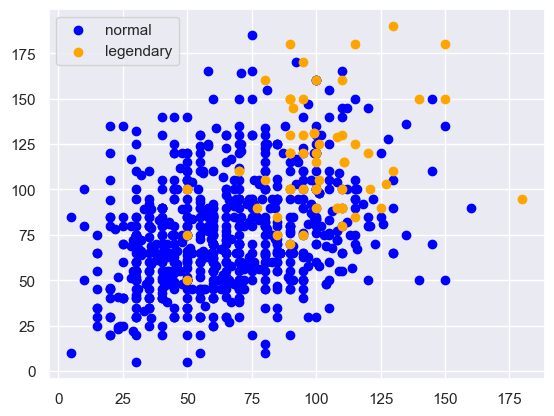

In [11]:
plt.scatter(pokemon.loc[~pokemon["Legendary"],"Speed"], pokemon.loc[~pokemon["Legendary"],"Attack"], color = "blue", label = "normal")
plt.scatter( pokemon.loc[pokemon["Legendary"],"Speed"], pokemon.loc[pokemon["Legendary"],"Attack"], color = "orange", label = "legendary" )
plt.legend()

The big question we once again ask ourself is the following: are the two variables completely independent from each other, or would we expect some kind of relationship based upon what we see? There is no direct metric of association we can calculate, but later on we will see how we can formally test associations.

As such, here it is extremely important that you learn to interpret the graph to decide which associations are worthy of investigations, and which aren't.